# Sentinel-2 data through the CDSE STAC API

This notebook searches Sentinel-2 products through the CDSE STAC API, inspects their metadata, and lazily reads bands with `stackstac`.

## Learning objectives

By the end, you should be able to:

1. define a geographic area and time interval;
2. query the CDSE STAC catalogue by collection, geometry and cloud cover;
3. inspect STAC items and assets;
4. construct a lazy, spatially aligned data cube; and
5. calculate and display a simple spectral index.

## 1. Install (only if needed)

CDSE JupyterLab images commonly already contain these packages. Uncomment the following line only when a package is missing.

In [1]:
# %pip install pystac-client stackstac geopandas shapely rasterio dask matplotlib boto3 pyproj contextily

## 2. Imports and CDSE object-storage settings

The STAC catalogue is public, but the raster assets are read from CDSE object storage. Create S3 credentials in the CDSE user area ([S3 Credentials → Add Credential](https://eodata-s3keysmanager.dataspace.copernicus.eu/panel/s3-credentials)), and save the secret key when it is shown because it cannot be displayed again.

The official CDSE STAC examples use the variables `CDSE_S3_ACCESS_KEY` and `CDSE_S3_SECRET_KEY`, then copy them to the standard AWS variables used by GDAL and `stackstac`. 

In [2]:
import os
from pathlib import Path
from getpass import getpass

import boto3
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import stackstac
from pyproj import CRS
from shapely.geometry import box
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from pystac_client.stac_api_io import StacApiIO

if not os.environ.get("CDSE_S3_ACCESS_KEY"):
    os.environ["CDSE_S3_ACCESS_KEY"] = getpass("CDSE S3 access key: " )
if not os.environ.get("CDSE_S3_SECRET_KEY"):
    os.environ["CDSE_S3_SECRET_KEY"] = getpass("CDSE S3 secret key: " )

os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_ACCESS_KEY_ID"] = os.environ["CDSE_S3_ACCESS_KEY"]
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ["CDSE_S3_SECRET_KEY"]
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

# Create the boto3 session only after the AWS variables are configured.
s3 = boto3.Session()
print("AWS credentials configured for this kernel.")

CDSE S3 access key:  ········
CDSE S3 secret key:  ········


AWS credentials configured for this kernel.


## 3. Define the area, dates and collection

Coordinates are written as `(west, south, east, north)` in WGS84 longitude/latitude. The example area is deliberately small so that later raster reads remain manageable. Replace it with your own bounding box or set `AOI_PATH` to a vector file available in the workspace.

The map uses `contextily` and Esri World Imagery tiles when available. This is only a background for orientation; the basemap is not used in the STAC query or analysis. If `contextily` is unavailable, the cell still plots the AOI without a basemap.

The CDSE collection used here is Sentinel-2 Level-2A (`sentinel-2-l2a`). For Level-1C exercises, change the value to `sentinel-2-l1c` and review the product scaling before quantitative analysis.

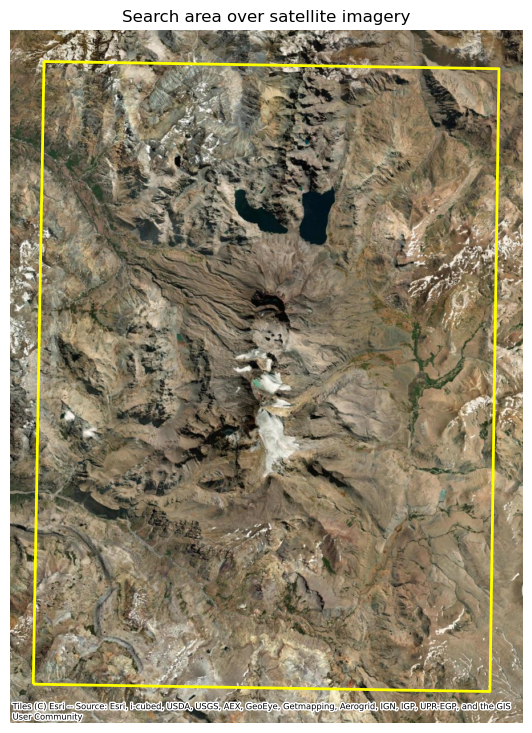

In [29]:
STAC_URL = "https://stac.dataspace.copernicus.eu/v1"
COLLECTION = "sentinel-2-l1c"
START_DATE = "2023-01-01"
END_DATE = "2023-01-10"
MAX_CLOUD_COVER = 80
AOI_PATH = Path("/mnt/CEPH_PROJECTS/SNOWCOP/Glaciers/Azufre/Azufre_extent.geojson")
#AOI_BBOX_WGS84 = [-70.20, -33.10, -70.00, -32.90]

if AOI_PATH is None:
    aoi = gpd.GeoDataFrame(geometry=[box(*AOI_BBOX_WGS84)], crs="EPSG:4326")
else:
    aoi = gpd.read_file(AOI_PATH).to_crs("EPSG:4326")

# contextily is optional; it downloads map tiles only for this visualization.
try:
    import contextily as ctx
except ImportError:
    ctx = None

if ctx is None:
    aoi.plot(edgecolor="red", facecolor="none")
    plt.title("Search area (WGS84; install contextily for a basemap)")
else:
    aoi_web = aoi.to_crs("EPSG:3857")
    ax = aoi_web.plot(edgecolor="yellow", facecolor="none", linewidth=2, figsize=(9, 9))
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution_size=6)
    ax.set_title("Search area over satellite imagery")
    ax.set_axis_off()
plt.show()

## 4. Open the catalogue and search

A STAC search returns metadata first; pixel data are not downloaded by this cell. The retry policy is useful for transient HTTP failures in a shared cloud environment.

In [30]:
retry = Retry(total=4, backoff_factor=0.5, status_forcelist=[429, 500, 502, 503, 504], allowed_methods=["GET"])
session = HTTPAdapter(max_retries=retry)
stac_io = StacApiIO()
stac_io.session.mount("https://", session)
catalog = pystac_client.Client.open(STAC_URL, stac_io=stac_io)

search = catalog.search(
    collections=[COLLECTION],
    intersects=aoi.geometry.iloc[0].__geo_interface__,
    datetime=f"{START_DATE}/{END_DATE}",
    query={"eo:cloud_cover": {"lte": MAX_CLOUD_COVER}},
)
items = list(search.items())
print(f"Found {len(items)} {COLLECTION} item(s).")

Found 8 sentinel-2-l1c item(s).


In [31]:
def item_table(stac_items):
    rows = []
    for item in stac_items:
        rows.append({
            "id": item.id,
            "datetime": item.datetime,
            "cloud_cover": item.properties.get("eo:cloud_cover"),
            "tile": item.properties.get("s2:mgrs_tile"),
            "platform": item.properties.get("platform"),
        })
    return pd.DataFrame(rows).sort_values("datetime")

items_df = item_table(items)
display(items_df.head())

,id,datetime,cloud_cover,tile,platform
6,S2B_MSIL1C_20230103T143729_N0510_R096_T19HCB_2...,2023-01-03 14:37:29.024000+00:00,0.00,None,sentinel-2b
7,S2B_MSIL1C_20230103T143729_N0510_R096_T19HCA_2...,2023-01-03 14:37:29.024000+00:00,0.00,None,sentinel-2b
4,S2A_MSIL1C_20230105T142711_N0510_R053_T19HCB_2...,2023-01-05 14:27:11.024000+00:00,6.05,None,sentinel-2a
5,S2A_MSIL1C_20230105T142711_N0510_R053_T19HCA_2...,2023-01-05 14:27:11.024000+00:00,0.37,None,sentinel-2a
2,S2A_MSIL1C_20230108T143731_N0510_R096_T19HCB_2...,2023-01-08 14:37:31.024000+00:00,5.51,None,sentinel-2a


### Exercise 1 — investigate the search result

Try the following without changing the search code structure:

- count the returned items per MGRS tile;
- display the least-cloudy item;
- change `MAX_CLOUD_COVER` to 20 and repeat the search;
- change the date range to a period with known acquisitions.

If the result is empty, first enlarge the date interval or cloud threshold, then verify the AOI and collection name.

In [32]:
if not items_df.empty:
    display(items_df.groupby("tile", dropna=False).size().rename("count"))
    display(items_df.nsmallest(1, "cloud_cover"))
else:
    print("No items: adjust the AOI, dates or cloud threshold.")

tile
NaN    8
Name: count, dtype: int64

,id,datetime,cloud_cover,tile,platform
6,S2B_MSIL1C_20230103T143729_N0510_R096_T19HCB_2...,2023-01-03 14:37:29.024000+00:00,0.0,None,sentinel-2b


## 5. Inspect assets

Each STAC item contains links to assets. The asset keys are the names passed to `stackstac`; inspect them rather than assuming that every collection exposes exactly the same set.

In [33]:
if items:
    first_item = items[0]
    for key, asset in first_item.assets.items():
        print(f"{key:>8}  {asset.media_type or 'unknown':<35}  {asset.title or ''}")
else:
    print("Run the search with a non-empty result first.")

     B01  image/jp2                            Coastal aerosol (band 1) - 60m
     B02  image/jp2                            Blue (band 2) - 10m
     B03  image/jp2                            Green (band 3) - 10m
     B04  image/jp2                            Red (band 4) - 10m
     B05  image/jp2                            Red edge 1 (band 5) - 20m
     B06  image/jp2                            Red edge 2 (band 6) - 20m
     B07  image/jp2                            Red edge 3 (band 7) - 20m
     B08  image/jp2                            NIR 1 (band 8) - 10m
     B09  image/jp2                            NIR 3 (band 9) - 60m
     B10  image/jp2                            Cirrus (band 10) - 60m
     B11  image/jp2                            SWIR 1 (band 11) - 20m
     B12  image/jp2                            SWIR 2 (band 12) - 20m
     B8A  image/jp2                            NIR 2 (band 8A) - 20m
     TCI  image/jp2                            True color image
 Product  application/z

## 6. Build a lazy Sentinel-2 data cube

`stackstac.stack` creates a Dask-backed array. The following cell does not load the complete cube into memory; computation starts when a plot or `.compute()` is requested. A 20 m target grid is used because it accommodates the 20 m bands without upsampling them to 10 m.

In [37]:
def utm_epsg(geometry):
    point = geometry.centroid
    zone = int((point.x + 180) // 6) + 1
    return 32600 + zone if point.y >= 0 else 32700 + zone

if not items:
    raise RuntimeError("No STAC items available; adjust the search parameters.")

target_crs = CRS.from_epsg(utm_epsg(aoi.geometry.iloc[0]))
bands = ["B02", "B03", "B04", "B08", "B11", "B12"]
bounds = tuple(aoi.to_crs(target_crs).total_bounds)
gdal_env = stackstac.DEFAULT_GDAL_ENV.updated({
    "GDAL_NUM_THREADS": -1,
    "GDAL_HTTP_UNSAFESSL": "YES",
    "GDAL_HTTP_TCP_KEEPALIVE": "YES",
    "AWS_VIRTUAL_HOSTING": "FALSE",
    "AWS_HTTPS": "YES"
})

cube = stackstac.stack(
    items,
    assets=bands,
    bounds=bounds,
    epsg=target_crs.to_epsg(),
    resolution=20,
    chunksize="auto",
    fill_value=np.nan,
    gdal_env=gdal_env,
)
print(cube)

<xarray.DataArray 'stackstac-8aaea8062d5d64f32561a71625f06084' (time: 8,
                                                                band: 6,
                                                                y: 1700, x: 1251)> Size: 817MB
dask.array<fetch_raster_window, shape=(8, 6, 1700, 1251), dtype=float64, chunksize=(2, 2, 1700, 1251), chunktype=numpy.ndarray>
Coordinates: (12/51)
  * time                                   (time) datetime64[ns] 64B 2023-01-...
    id                                     (time) <U60 2kB 'S2B_MSIL1C_202301...
  * band                                   (band) <U3 72B 'B02' 'B03' ... 'B12'
  * x                                      (x) float64 10kB 3.44e+05 ... 3.69...
  * y                                      (y) float64 14kB 6.114e+06 ... 6.0...
    eopf:datatake_id                       (time) <U34 1kB 'GS2B_20230103T143...
    ...                                     ...
    nodata                                 int64 8B 0
    proj:code          

## 7. Display a true-colour composite

The bands are returned in the order requested above. Sentinel-2 L2A reflectances are scaled values, so the percentile stretch below is intended for display, not for scientific calibration.

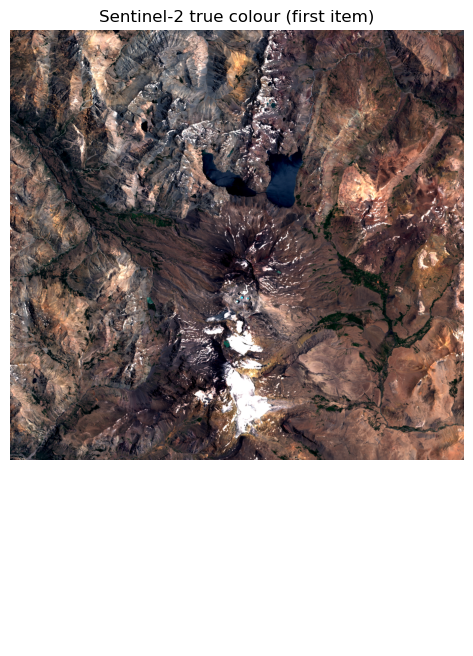

In [38]:
rgb = cube.sel(band=["B04", "B03", "B02"]).isel(time=0).compute()
rgb_values = np.asarray(rgb)
low, high = np.nanpercentile(rgb_values, [2, 98])
rgb_display = np.clip((rgb_values - low) / (high - low), 0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(np.moveaxis(rgb_display, 0, -1))
plt.title("Sentinel-2 true colour (first item)")
plt.axis("off")
plt.show()

## 8. Calculate NDVI

NDVI is `(NIR - red) / (NIR + red)`, using B08 and B04. The small denominator guard avoids invalid divisions over no-data pixels.

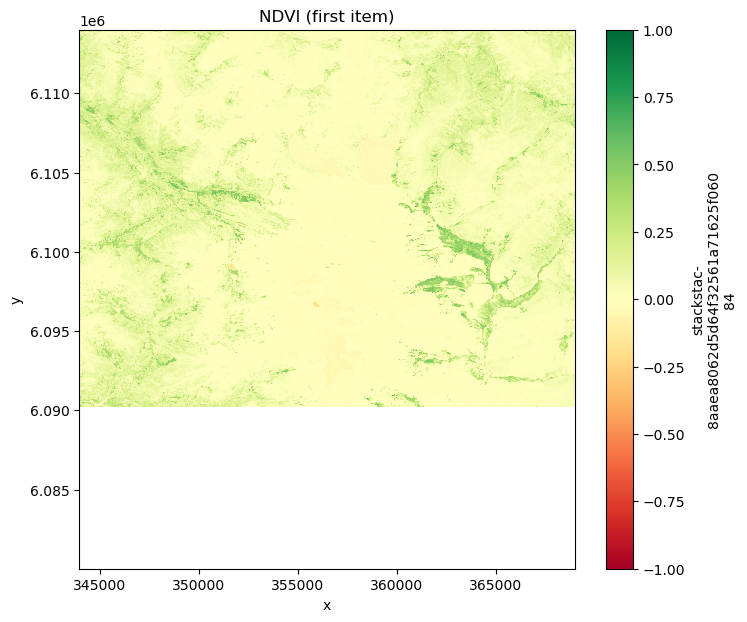

In [43]:
nir = cube.sel(band="B08")
red = cube.sel(band="B04")
denominator = nir + red
ndvi = ((nir - red) / denominator).where(np.abs(denominator) > 1e-6)

ndvi_first = ndvi.isel(time=0).compute()
plt.figure(figsize=(8, 7))
ndvi_first.plot(cmap="RdYlGn", vmin=-1, vmax=1)
plt.title("NDVI (first item)")
plt.show()

## Suggested extensions

1. Select the least-cloudy item rather than `time=0`.
2. Plot the mean NDVI over the AOI for every acquisition date.
3. Compare 10 m and 20 m resolutions and explain the change in array size.
4. Add a stricter cloud-cover filter and compare the temporal sampling.
5. Mask pixels using the Sentinel-2 scene-classification (`SCL`) asset, after confirming that the asset is present in the item.

Keep the search and raster-reading stages separate: this makes it easier to inspect metadata, control data volume, and reproduce an exercise.